# 05 — Double Machine Learning: Causal Effect Estimation
## EconoCausal: Dynamic Pricing & Marketing Uplift via Double Machine Learning

---

### Executive Summary

This notebook is the **core estimation engine** of the EconoCausal project.  We move
from *identification* (Notebook 03) and *propensity diagnostics* (Notebook 04) to
**causal effect estimation** using **Double Machine Learning (DML)**.

#### Why Double Machine Learning?

Naive regression of $Y$ on $T$ and $X$ conflates the causal effect with
regularization bias introduced by high-dimensional nuisance estimation.
DML resolves this by **orthogonalizing** the treatment and outcome against the
confounders before estimating the causal parameter.

#### Robinson's Partially-Linear Model

DML implements Robinson's (1988) transformation in three steps:

1. **Outcome nuisance model** — learn the conditional expectation of the outcome:
$$m(X) = \mathbb{E}[Y \mid X]$$

2. **Treatment nuisance model** — learn the conditional expectation (propensity) of
   the treatment:
$$e(X) = \mathbb{E}[T \mid X]$$

3. **Residualize** and regress:
$$\widetilde{Y} = Y - \hat{m}(X), \qquad \widetilde{T} = T - \hat{e}(X)$$
$$\widetilde{Y} = \theta(X)\,\widetilde{T} + \varepsilon$$

where $\theta(X)$ is the **Conditional Average Treatment Effect (CATE)**.

#### Key Properties of DML

| Property | Description |
|----------|-------------|
| **$\sqrt{N}$-consistency** | The causal parameter converges at the parametric rate even when nuisance models are nonparametric. |
| **Neyman orthogonality** | First-order errors in nuisance estimation do not bias the causal estimate. |
| **Cross-fitting** | Sample splitting eliminates overfitting bias from nuisance model reuse. |

#### Estimands

| Estimand | Definition | Outcome |
|----------|-----------|---------|
| **ATE** | $\mathbb{E}[Y(1) - Y(0)]$ | Population-average treatment effect |
| **CATE** | $\mathbb{E}[Y(1) - Y(0) \mid X = x]$ | Heterogeneous effect conditional on features |
| **ITE** | $\hat{\theta}(X_i)$ for individual $i$ | Individual-level predicted uplift |

#### Scope & Constraints

- This notebook estimates causal effects **only**.  Business rules, segmentation,
  and campaign targeting logic are deferred to Notebooks 06+.
- We estimate effects for **two treatment comparisons**:
  - Men's E-Mail vs. No E-Mail
  - Women's E-Mail vs. No E-Mail
- We estimate effects for **two outcomes**:
  - `conversion` (binary)
  - `spend` (continuous, zero-inflated)


## 2. Environment Setup & Dependency Configuration

In [7]:
# ---------------------------------------------------------------------------
# 2.1  Core Imports
# ---------------------------------------------------------------------------
import os
import sys
import json
import logging
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Lasso, LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ---------------------------------------------------------------------------
# 2.2  Causal ML Imports (with graceful fallback)
# ---------------------------------------------------------------------------
try:
    from econml.dml import LinearDML, CausalForestDML, SparseLinearDML
    from econml.inference import BootstrapInference
    ECONML_AVAILABLE = True
    import econml
    print(f"EconML version: {econml.__version__}")
except ImportError:
    ECONML_AVAILABLE = False
    print("WARNING: econml not installed. Install via: pip install econml")

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
    print(f"LightGBM version: {lgb.__version__}")
except ImportError:
    LGBM_AVAILABLE = False
    print("WARNING: lightgbm not installed. Using sklearn GradientBoosting as fallback.")

# ---------------------------------------------------------------------------
# 2.3  Configuration
# ---------------------------------------------------------------------------
RANDOM_SEED: int = 42
N_FOLDS: int = 5          # Cross-fitting folds for DML
N_JOBS: int = -1           # Parallelism

np.random.seed(RANDOM_SEED)

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger(__name__)

# Suppress non-critical warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Plotting aesthetics
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.family": "serif"
})
pd.set_option("display.max_columns", None)

logger.info("Environment configured successfully.")


2026-09-28 15:57:34 [INFO] Environment configured successfully.


EconML version: 0.17.0
LightGBM version: 4.7.0


## 3. Loading & Inspecting Estimation Artifacts

We load the upstream artifacts produced by Notebooks 02-04:

| Artifact | Source | Purpose |
|----------|--------|---------|
| Raw dataset CSV | Notebook 01 | Source data |
| `causal_formulation.json` | Notebook 03 | Backdoor adjustment set, effect modifiers |
| `causal_dag.gml` | Notebook 03 | Structural causal graph |
| Propensity models (`.pkl`) | Notebook 04 | Pre-fitted treatment models |


In [8]:
# ---------------------------------------------------------------------------
# 3.1  Path Configuration
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path("..").resolve()
MODELS_DIR = PROJECT_ROOT / "models"
DATA_PATHS = [
    PROJECT_ROOT / "Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv",
    Path("Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"),
    PROJECT_ROOT / "datasets" / "raw" / "Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
]

# ---------------------------------------------------------------------------
# 3.2  Load Raw Data
# ---------------------------------------------------------------------------
dataset_path = next((p for p in DATA_PATHS if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Hillstrom dataset CSV not found. Check project directory.")

df = pd.read_csv(dataset_path)
df = df.drop_duplicates().reset_index(drop=True)
logger.info(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns from {dataset_path.name}")

# ---------------------------------------------------------------------------
# 3.3  Load Causal Formulation
# ---------------------------------------------------------------------------
causal_formulation_path = MODELS_DIR / "causal_formulation.json"
if causal_formulation_path.exists():
    with open(causal_formulation_path, "r") as f:
        causal_formulation = json.load(f)
    logger.info(f"Causal formulation loaded: {causal_formulation}")
else:
    logger.warning("causal_formulation.json not found. Using defaults.")
    causal_formulation = {
        "identification_strategy": "backdoor",
        "identified_backdoor_variables": ["History", "Recency", "ZipCode", "Channel", "Newbie"],
        "effect_modifiers": ["History", "Recency", "Newbie"],
        "excluded_colliders": ["Website_Visit"],
        "target_1": "conversion",
        "target_2": "spend"
    }

# ---------------------------------------------------------------------------
# 3.4  Load Propensity Models
# ---------------------------------------------------------------------------
propensity_models = {}
for name in ["mens_propensity_model", "womens_propensity_model", "multiclass_propensity_model"]:
    path = MODELS_DIR / f"{name}.pkl"
    if path.exists():
        propensity_models[name] = joblib.load(path)
        logger.info(f"Loaded: {name}")
    else:
        logger.warning(f"Not found: {path}")

print(f"\nPropensity models loaded: {list(propensity_models.keys())}")


2026-09-28 15:57:35 [INFO] Dataset loaded: 57,438 rows x 12 columns from Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv
2026-09-28 15:57:35 [INFO] Causal formulation loaded: {'identification_strategy': 'backdoor', 'identified_backdoor_variables': ['History', 'Recency', 'ZipCode', 'Channel', 'Newbie'], 'effect_modifiers': ['History', 'Recency', 'Newbie'], 'excluded_colliders': ['Website_Visit'], 'target_1': 'conversion', 'target_2': 'spend'}
2026-09-28 15:57:35 [INFO] Loaded: mens_propensity_model
2026-09-28 15:57:35 [INFO] Loaded: womens_propensity_model
2026-09-28 15:57:35 [INFO] Loaded: multiclass_propensity_model



Propensity models loaded: ['mens_propensity_model', 'womens_propensity_model', 'multiclass_propensity_model']


## 4. DML Estimation Problem Specification

### Variable Architecture

We strictly separate our variables to maintain causal correctness:

| Role | Variables | Rationale |
|------|-----------|-----------|
| **Confounders / Controls ($W$)** | `recency`, `history`, `history_segment`, `mens`, `womens`, `zip_code`, `newbie`, `channel` | Pre-treatment covariates in the backdoor adjustment set |
| **Treatment ($T$)** | `segment` -> binary: Treatment vs. Control | Randomized marketing email assignment |
| **Outcomes ($Y$)** | `conversion` (binary), `spend` (continuous) | Post-treatment response variables |
| **Effect Modifiers ($V$)** | `history`, `recency`, `newbie` | Features hypothesized to drive treatment heterogeneity |
| **Excluded (collider)** | `visit` | Post-treatment mediator - conditioning would introduce collider bias |

### Why DML over Naive Regression?

In a naive regression $Y \sim T + X$, if $X$ is high-dimensional and we regularize
(e.g., Lasso), the regularization bias **leaks into the treatment coefficient**.
DML removes this by orthogonalizing $T$ and $Y$ against $X$ before estimating
$\theta$.  In an RCT like Hillstrom, DML provides **efficiency gains** and
**heterogeneity recovery** even though the ATE is unbiased by simple difference-in-means.


In [9]:
# ---------------------------------------------------------------------------
# 4.1  Treatment Encoding
# ---------------------------------------------------------------------------
TREATMENT_COL = "segment"
TREATMENT_MAPPING = {
    "No E-Mail": 0,
    "Mens E-Mail": 1,
    "Womens E-Mail": 2
}
df["treatment"] = df[TREATMENT_COL].map(TREATMENT_MAPPING)

if df["treatment"].isnull().any():
    raise ValueError(f"Unknown treatment values: {df.loc[df['treatment'].isnull(), TREATMENT_COL].unique()}")

# ---------------------------------------------------------------------------
# 4.2  Covariate Definition (pre-treatment only)
# ---------------------------------------------------------------------------
COVARIATE_COLS: List[str] = [
    "recency", "history_segment", "history",
    "mens", "womens", "zip_code", "newbie", "channel"
]

# Effect modifiers - subset of covariates expected to drive heterogeneity
EFFECT_MODIFIER_COLS: List[str] = ["history", "recency", "newbie"]

# Outcome columns
OUTCOME_COLS: List[str] = ["conversion", "spend"]

# Excluded post-treatment variables (NOT used anywhere in DML)
EXCLUDED_POST_TREATMENT: List[str] = ["visit"]

logger.info(f"Covariates ({len(COVARIATE_COLS)}): {COVARIATE_COLS}")
logger.info(f"Effect Modifiers: {EFFECT_MODIFIER_COLS}")
logger.info(f"Outcomes: {OUTCOME_COLS}")
logger.info(f"Excluded post-treatment: {EXCLUDED_POST_TREATMENT}")

# Verify no post-treatment variables in covariate list
for col in EXCLUDED_POST_TREATMENT:
    assert col not in COVARIATE_COLS, f"CAUSAL ERROR: Post-treatment variable '{col}' found in covariates!"
logger.info("Causal integrity check PASSED: no post-treatment variables in covariates.")


2026-09-28 15:57:35 [INFO] Covariates (8): ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
2026-09-28 15:57:35 [INFO] Effect Modifiers: ['history', 'recency', 'newbie']
2026-09-28 15:57:35 [INFO] Outcomes: ['conversion', 'spend']
2026-09-28 15:57:35 [INFO] Excluded post-treatment: ['visit']
2026-09-28 15:57:35 [INFO] Causal integrity check PASSED: no post-treatment variables in covariates.


## 5. Feature Preprocessing for Nuisance Models

We build a `ColumnTransformer` pipeline that processes the pre-treatment covariates
into a numerical feature matrix suitable for nuisance learners.

This mirrors the preprocessing established in Notebook 04, ensuring consistency
across the pipeline.


In [10]:
# ---------------------------------------------------------------------------
# 5.1  Feature Type Separation
# ---------------------------------------------------------------------------
NUMERIC_FEATURES: List[str] = ["recency", "history"]
BINARY_FEATURES: List[str] = ["mens", "womens", "newbie"]
CATEGORICAL_FEATURES: List[str] = ["zip_code", "channel", "history_segment"]

# ---------------------------------------------------------------------------
# 5.2  Build ColumnTransformer
# ---------------------------------------------------------------------------
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

dml_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("binary", binary_pipeline, BINARY_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES)
    ],
    remainder="drop"
)

logger.info("DML preprocessing pipeline constructed.")

# ---------------------------------------------------------------------------
# 5.3  Prepare Pairwise Subsets
# ---------------------------------------------------------------------------
def prepare_dml_data(
    df: pd.DataFrame,
    treatment_value: int,
    control_value: int = 0,
    outcome_col: str = "conversion"
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Prepare DML-ready arrays for a binary treatment comparison.

    Parameters
    ----------
    df : pd.DataFrame
        Full dataset with 'treatment' column.
    treatment_value : int
        Numeric code for the treatment arm (1=Mens, 2=Womens).
    control_value : int
        Numeric code for the control arm (default 0=No Email).
    outcome_col : str
        Name of the outcome variable.

    Returns
    -------
    X : np.ndarray  - Preprocessed covariate matrix
    T : np.ndarray  - Binary treatment indicator
    Y : np.ndarray  - Outcome vector
    X_effect : np.ndarray - Effect modifier matrix (subset of X)
    subset_df : pd.DataFrame - The filtered dataframe
    """
    mask = df["treatment"].isin([control_value, treatment_value])
    subset_df = df.loc[mask].copy().reset_index(drop=True)

    T = (subset_df["treatment"] == treatment_value).astype(int).values
    Y = subset_df[outcome_col].values.astype(float)

    # Fit-transform covariates
    X = dml_preprocessor.fit_transform(subset_df[COVARIATE_COLS])

    # Effect modifiers (raw numeric values for interpretability)
    X_effect = subset_df[EFFECT_MODIFIER_COLS].values.astype(float)

    logger.info(
        f"Prepared: T={treatment_value} vs T={control_value}, "
        f"outcome={outcome_col}, n={len(T):,}, "
        f"treated={T.sum():,}, control={(1-T).sum():,}"
    )
    return X, T, Y, X_effect, subset_df

# Test: Mens vs Control - Conversion
X_mens_conv, T_mens, Y_mens_conv, X_eff_mens, df_mens = prepare_dml_data(
    df, treatment_value=1, outcome_col="conversion"
)
print(f"Mens vs Control (conversion): X={X_mens_conv.shape}, T_mean={T_mens.mean():.3f}, Y_mean={Y_mens_conv.mean():.4f}")

# Test: Womens vs Control - Conversion
X_womens_conv, T_womens, Y_womens_conv, X_eff_womens, df_womens = prepare_dml_data(
    df, treatment_value=2, outcome_col="conversion"
)
print(f"Womens vs Control (conversion): X={X_womens_conv.shape}, T_mean={T_womens.mean():.3f}, Y_mean={Y_womens_conv.mean():.4f}")


2026-09-28 15:57:35 [INFO] DML preprocessing pipeline constructed.
2026-09-28 15:57:35 [INFO] Prepared: T=1 vs T=0, outcome=conversion, n=38,264, treated=19,183, control=19,081
2026-09-28 15:57:35 [INFO] Prepared: T=2 vs T=0, outcome=conversion, n=38,255, treated=19,174, control=19,081


Mens vs Control (conversion): X=(38264, 15), T_mean=0.501, Y_mean=0.0102
Womens vs Control (conversion): X=(38255, 15), T_mean=0.501, Y_mean=0.0081


## 6. Nuisance Model Design

The quality of DML estimates depends on the quality of the nuisance models
$\hat{m}(X) = \mathbb{E}[Y|X]$ and $\hat{e}(X) = \mathbb{E}[T|X]$.

### Design Choices

| Component | Binary Outcome (`conversion`) | Continuous Outcome (`spend`) |
|-----------|-------------------------------|------------------------------|
| **Treatment model $\hat{e}(X)$** | `LogisticRegression` or `LGBMClassifier` | Same (treatment is always binary) |
| **Outcome model $\hat{m}(X)$** | `GradientBoostingClassifier` or `LGBMClassifier` | `GradientBoostingRegressor` or `LGBMRegressor` |

### Why Cross-Fitting?

Without cross-fitting, nuisance models are trained and predicted on the same data,
introducing overfitting bias.  DML uses $K$-fold sample splitting: for each fold $k$,
the nuisance models are trained on all folds except $k$ and predictions are made
on fold $k$.  This ensures out-of-sample predictions throughout.


In [11]:
# ---------------------------------------------------------------------------
# 6.1  Nuisance Model Factories
# ---------------------------------------------------------------------------
def get_treatment_model(model_type: str = "auto"):
    """Return a classifier for the treatment nuisance model e(X)."""
    if model_type == "auto" and LGBM_AVAILABLE:
        return lgb.LGBMClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_SEED,
            verbose=-1
        )
    else:
        return GradientBoostingClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            random_state=RANDOM_SEED
        )


def get_outcome_model_classifier(model_type: str = "auto"):
    """Return a classifier for binary outcome nuisance model m(X)."""
    if model_type == "auto" and LGBM_AVAILABLE:
        return lgb.LGBMClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_SEED,
            verbose=-1
        )
    else:
        return GradientBoostingClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            random_state=RANDOM_SEED
        )


def get_outcome_model_regressor(model_type: str = "auto"):
    """Return a regressor for continuous outcome nuisance model m(X)."""
    if model_type == "auto" and LGBM_AVAILABLE:
        return lgb.LGBMRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_SEED,
            verbose=-1
        )
    else:
        return GradientBoostingRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            random_state=RANDOM_SEED
        )


logger.info(f"Nuisance model backend: {'LightGBM' if LGBM_AVAILABLE else 'sklearn GradientBoosting'}")


2026-09-28 15:57:35 [INFO] Nuisance model backend: LightGBM


## 7. Double Machine Learning Estimators

### 7.1 LinearDML

`LinearDML` assumes a linear relationship between the CATE and the effect modifiers:

$$\theta(X) = X_V^{\top} \beta$$

This is the simplest DML estimator and provides interpretable coefficients for the
effect modifiers.  It is well-suited for hypothesis testing and confidence interval
construction.


In [12]:
# ======================================================================
# 7.1  LinearDML - Conversion Uplift
# ======================================================================
if not ECONML_AVAILABLE:
    raise ImportError("EconML is required for DML estimation. Install via: pip install econml")

# --- Mens vs Control: Conversion ---
logger.info("Fitting LinearDML: Mens vs Control - Conversion")

linear_dml_mens_conv = LinearDML(
    model_y=get_outcome_model_classifier(),
    discrete_outcome=True,
    model_t=get_treatment_model(),
    discrete_treatment=True,
    cv=N_FOLDS,
    random_state=RANDOM_SEED
)

linear_dml_mens_conv.fit(
    Y=Y_mens_conv,
    T=T_mens,
    X=X_eff_mens,
    W=X_mens_conv
)

# ATE
ate_mens_conv = np.mean(linear_dml_mens_conv.ate(X=X_eff_mens))
ate_mens_conv_inference = linear_dml_mens_conv.ate_inference(X=X_eff_mens)

print("=" * 70)
print("LinearDML - Mens E-Mail vs. No E-Mail: CONVERSION")
print("=" * 70)
print(f"ATE (Average Treatment Effect): {np.mean(ate_mens_conv):.6f}")
print(f"ATE 95% CI: [{np.mean(ate_mens_conv_inference.conf_int_mean()[0]):.6f}, {np.mean(ate_mens_conv_inference.conf_int_mean()[1]):.6f}]")
print(f"ATE p-value: {np.mean(ate_mens_conv_inference.pvalue()):.6f}")
print()

# CATE predictions
cate_mens_conv = linear_dml_mens_conv.effect(X=X_eff_mens)
print(f"CATE distribution - mean: {cate_mens_conv.mean():.6f}, std: {cate_mens_conv.std():.6f}")
print(f"CATE range: [{cate_mens_conv.min():.6f}, {cate_mens_conv.max():.6f}]")


2026-09-28 15:57:35 [INFO] Fitting LinearDML: Mens vs Control - Conversion


LinearDML - Mens E-Mail vs. No E-Mail: CONVERSION
ATE (Average Treatment Effect): 0.007198
ATE 95% CI: [0.005189, 0.009207]
ATE p-value: 0.000000

CATE distribution - mean: 0.007198, std: 0.001786
CATE range: [0.005065, 0.028354]


In [13]:
# --- Womens vs Control: Conversion ---
logger.info("Fitting LinearDML: Womens vs Control - Conversion")

linear_dml_womens_conv = LinearDML(
    model_y=get_outcome_model_classifier(),
    discrete_outcome=True,
    model_t=get_treatment_model(),
    discrete_treatment=True,
    cv=N_FOLDS,
    random_state=RANDOM_SEED
)

linear_dml_womens_conv.fit(
    Y=Y_womens_conv,
    T=T_womens,
    X=X_eff_womens,
    W=X_womens_conv
)

ate_womens_conv = np.mean(linear_dml_womens_conv.ate(X=X_eff_womens))
ate_womens_conv_inference = linear_dml_womens_conv.ate_inference(X=X_eff_womens)

print("=" * 70)
print("LinearDML - Womens E-Mail vs. No E-Mail: CONVERSION")
print("=" * 70)
print(f"ATE: {np.mean(ate_womens_conv):.6f}")
print(f"ATE 95% CI: [{np.mean(ate_womens_conv_inference.conf_int_mean()[0]):.6f}, {np.mean(ate_womens_conv_inference.conf_int_mean()[1]):.6f}]")
print(f"ATE p-value: {np.mean(ate_womens_conv_inference.pvalue()):.6f}")
print()

cate_womens_conv = linear_dml_womens_conv.effect(X=X_eff_womens)
print(f"CATE distribution - mean: {cate_womens_conv.mean():.6f}, std: {cate_womens_conv.std():.6f}")


2026-09-28 15:57:39 [INFO] Fitting LinearDML: Womens vs Control - Conversion


LinearDML - Womens E-Mail vs. No E-Mail: CONVERSION
ATE: 0.003507
ATE 95% CI: [0.001702, 0.005312]
ATE p-value: 0.000140

CATE distribution - mean: 0.003507, std: 0.002628


### 7.2  LinearDML - Spend (Revenue) Uplift

#### Zero-Inflation Challenge

The `spend` variable is **zero-inflated**: the vast majority of customers spend \$0.
This means:

- The outcome distribution has a **point mass at zero** and a **right-skewed continuous
  component**.
- A standard regression nuisance model may underfit the continuous part or overfit
  the zero mass.

#### Our Approach

We apply DML **directly on the full `spend` variable** (including zeros).  This
estimates the **intention-to-treat (ITT) effect on revenue** - the expected change in
spend when a customer is *assigned* to treatment, regardless of whether they purchase.

This is the appropriate estimand for marketing campaign evaluation because campaign
costs apply to all assigned customers, not only purchasers.


In [14]:
# --- Mens vs Control: Spend ---
X_mens_spend, T_mens_s, Y_mens_spend, X_eff_mens_s, df_mens_s = prepare_dml_data(
    df, treatment_value=1, outcome_col="spend"
)

logger.info("Fitting LinearDML: Mens vs Control - Spend")

linear_dml_mens_spend = LinearDML(
    model_y=get_outcome_model_regressor(),
    model_t=get_treatment_model(),
    discrete_treatment=True,
    cv=N_FOLDS,
    random_state=RANDOM_SEED
)

linear_dml_mens_spend.fit(
    Y=Y_mens_spend,
    T=T_mens_s,
    X=X_eff_mens_s,
    W=X_mens_spend
)

ate_mens_spend = np.mean(linear_dml_mens_spend.ate(X=X_eff_mens_s))
ate_mens_spend_inf = linear_dml_mens_spend.ate_inference(X=X_eff_mens_s)

print("=" * 70)
print("LinearDML - Mens E-Mail vs. No E-Mail: SPEND")
print("=" * 70)
print(f"ATE: ${np.mean(ate_mens_spend):.4f}")
print(f"ATE 95% CI: [${np.mean(ate_mens_spend_inf.conf_int_mean()[0]):.4f}, ${np.mean(ate_mens_spend_inf.conf_int_mean()[1]):.4f}]")
print(f"ATE p-value: {np.mean(ate_mens_spend_inf.pvalue()):.6f}")
print()

cate_mens_spend = linear_dml_mens_spend.effect(X=X_eff_mens_s)
print(f"CATE distribution - mean: ${cate_mens_spend.mean():.4f}, std: ${cate_mens_spend.std():.4f}")
print(f"CATE range: [${cate_mens_spend.min():.4f}, ${cate_mens_spend.max():.4f}]")


2026-09-28 15:57:43 [INFO] Prepared: T=1 vs T=0, outcome=spend, n=38,264, treated=19,183, control=19,081
2026-09-28 15:57:43 [INFO] Fitting LinearDML: Mens vs Control - Spend


LinearDML - Mens E-Mail vs. No E-Mail: SPEND
ATE: $0.8169
ATE 95% CI: [$0.4922, $1.1416]
ATE p-value: 0.000001

CATE distribution - mean: $0.8169, std: $0.2464
CATE range: [$0.4712, $2.7688]


In [15]:
# --- Womens vs Control: Spend ---
X_womens_spend, T_womens_s, Y_womens_spend, X_eff_womens_s, df_womens_s = prepare_dml_data(
    df, treatment_value=2, outcome_col="spend"
)

logger.info("Fitting LinearDML: Womens vs Control - Spend")

linear_dml_womens_spend = LinearDML(
    model_y=get_outcome_model_regressor(),
    model_t=get_treatment_model(),
    discrete_treatment=True,
    cv=N_FOLDS,
    random_state=RANDOM_SEED
)

linear_dml_womens_spend.fit(
    Y=Y_womens_spend,
    T=T_womens_s,
    X=X_eff_womens_s,
    W=X_womens_spend
)

ate_womens_spend = np.mean(linear_dml_womens_spend.ate(X=X_eff_womens_s))
ate_womens_spend_inf = linear_dml_womens_spend.ate_inference(X=X_eff_womens_s)

print("=" * 70)
print("LinearDML - Womens E-Mail vs. No E-Mail: SPEND")
print("=" * 70)
print(f"ATE: ${np.mean(ate_womens_spend):.4f}")
print(f"ATE 95% CI: [${np.mean(ate_womens_spend_inf.conf_int_mean()[0]):.4f}, ${np.mean(ate_womens_spend_inf.conf_int_mean()[1]):.4f}]")
print(f"ATE p-value: {np.mean(ate_womens_spend_inf.pvalue()):.6f}")
print()

cate_womens_spend = linear_dml_womens_spend.effect(X=X_eff_womens_s)
print(f"CATE distribution - mean: ${cate_womens_spend.mean():.4f}, std: ${cate_womens_spend.std():.4f}")


2026-09-28 15:57:48 [INFO] Prepared: T=2 vs T=0, outcome=spend, n=38,255, treated=19,174, control=19,081
2026-09-28 15:57:48 [INFO] Fitting LinearDML: Womens vs Control - Spend


LinearDML - Womens E-Mail vs. No E-Mail: SPEND
ATE: $0.4960
ATE 95% CI: [$0.2070, $0.7849]
ATE p-value: 0.000768

CATE distribution - mean: $0.4960, std: $0.3747


### 7.3 CausalForestDML

`CausalForestDML` uses a **causal forest** as the final-stage estimator for $\theta(X)$.
Unlike `LinearDML`, it does **not** assume a linear relationship between CATE and
effect modifiers.  It can capture arbitrarily complex heterogeneity patterns.

Key properties:
- **Nonparametric** CATE estimation
- **Honesty**: separate samples for tree splitting and estimation within each tree
- **Asymptotically normal** pointwise confidence intervals
- Better for discovering subgroups with large/small treatment effects


In [16]:
# ======================================================================
# 7.3  CausalForestDML - Conversion
# ======================================================================
logger.info("Fitting CausalForestDML: Mens vs Control - Conversion")

cf_dml_mens_conv = CausalForestDML(
    model_y=get_outcome_model_classifier(),
    discrete_outcome=True,
    model_t=get_treatment_model(),
    discrete_treatment=True,
    cv=N_FOLDS,
    n_estimators=200,
    min_samples_leaf=20,
    max_depth=10,
    random_state=RANDOM_SEED
)

cf_dml_mens_conv.fit(
    Y=Y_mens_conv,
    T=T_mens,
    X=X_eff_mens,
    W=X_mens_conv
)

ate_cf_mens_conv = np.mean(cf_dml_mens_conv.ate(X=X_eff_mens))
ate_cf_mens_conv_inf = cf_dml_mens_conv.ate_inference(X=X_eff_mens)

print("=" * 70)
print("CausalForestDML - Mens E-Mail vs. No E-Mail: CONVERSION")
print("=" * 70)
print(f"ATE: {np.mean(ate_cf_mens_conv):.6f}")
print(f"ATE 95% CI: [{np.mean(ate_cf_mens_conv_inf.conf_int_mean()[0]):.6f}, {np.mean(ate_cf_mens_conv_inf.conf_int_mean()[1]):.6f}]")
print()

cate_cf_mens_conv = cf_dml_mens_conv.effect(X=X_eff_mens)
print(f"CATE distribution - mean: {cate_cf_mens_conv.mean():.6f}, std: {cate_cf_mens_conv.std():.6f}")
print(f"CATE range: [{cate_cf_mens_conv.min():.6f}, {cate_cf_mens_conv.max():.6f}]")


2026-09-28 15:57:52 [INFO] Fitting CausalForestDML: Mens vs Control - Conversion


CausalForestDML - Mens E-Mail vs. No E-Mail: CONVERSION
ATE: 0.007342
ATE 95% CI: [-0.010068, 0.024752]

CATE distribution - mean: 0.007342, std: 0.008421
CATE range: [-0.035545, 0.059691]


In [17]:
# --- CausalForestDML: Womens vs Control - Conversion ---
logger.info("Fitting CausalForestDML: Womens vs Control - Conversion")

cf_dml_womens_conv = CausalForestDML(
    model_y=get_outcome_model_classifier(),
    discrete_outcome=True,
    model_t=get_treatment_model(),
    discrete_treatment=True,
    cv=N_FOLDS,
    n_estimators=200,
    min_samples_leaf=20,
    max_depth=10,
    random_state=RANDOM_SEED
)

cf_dml_womens_conv.fit(
    Y=Y_womens_conv,
    T=T_womens,
    X=X_eff_womens,
    W=X_womens_conv
)

ate_cf_womens_conv = np.mean(cf_dml_womens_conv.ate(X=X_eff_womens))
ate_cf_womens_conv_inf = cf_dml_womens_conv.ate_inference(X=X_eff_womens)

print("=" * 70)
print("CausalForestDML - Womens E-Mail vs. No E-Mail: CONVERSION")
print("=" * 70)
print(f"ATE: {np.mean(ate_cf_womens_conv):.6f}")
print(f"ATE 95% CI: [{np.mean(ate_cf_womens_conv_inf.conf_int_mean()[0]):.6f}, {np.mean(ate_cf_womens_conv_inf.conf_int_mean()[1]):.6f}]")
print()

cate_cf_womens_conv = cf_dml_womens_conv.effect(X=X_eff_womens)
print(f"CATE - mean: {cate_cf_womens_conv.mean():.6f}, std: {cate_cf_womens_conv.std():.6f}")


2026-09-28 15:58:02 [INFO] Fitting CausalForestDML: Womens vs Control - Conversion


CausalForestDML - Womens E-Mail vs. No E-Mail: CONVERSION
ATE: 0.003509
ATE 95% CI: [-0.012852, 0.019869]

CATE - mean: 0.003509, std: 0.008168


In [18]:
# ======================================================================
# 7.3  CausalForestDML - Spend
# ======================================================================
logger.info("Fitting CausalForestDML: Mens vs Control - Spend")

cf_dml_mens_spend = CausalForestDML(
    model_y=get_outcome_model_regressor(),
    model_t=get_treatment_model(),
    discrete_treatment=True,
    cv=N_FOLDS,
    n_estimators=200,
    min_samples_leaf=20,
    max_depth=10,
    random_state=RANDOM_SEED
)

cf_dml_mens_spend.fit(
    Y=Y_mens_spend,
    T=T_mens_s,
    X=X_eff_mens_s,
    W=X_mens_spend
)

ate_cf_mens_spend = np.mean(cf_dml_mens_spend.ate(X=X_eff_mens_s))
print(f"CausalForestDML - Mens Spend ATE: ${np.mean(ate_cf_mens_spend):.4f}")

cate_cf_mens_spend = cf_dml_mens_spend.effect(X=X_eff_mens_s)
print(f"CATE - mean: ${cate_cf_mens_spend.mean():.4f}, std: ${cate_cf_mens_spend.std():.4f}")

# Womens
logger.info("Fitting CausalForestDML: Womens vs Control - Spend")

cf_dml_womens_spend = CausalForestDML(
    model_y=get_outcome_model_regressor(),
    model_t=get_treatment_model(),
    discrete_treatment=True,
    cv=N_FOLDS,
    n_estimators=200,
    min_samples_leaf=20,
    max_depth=10,
    random_state=RANDOM_SEED
)

cf_dml_womens_spend.fit(
    Y=Y_womens_spend,
    T=T_womens_s,
    X=X_eff_womens_s,
    W=X_womens_spend
)

ate_cf_womens_spend = np.mean(cf_dml_womens_spend.ate(X=X_eff_womens_s))
print(f"CausalForestDML - Womens Spend ATE: ${np.mean(ate_cf_womens_spend):.4f}")

cate_cf_womens_spend = cf_dml_womens_spend.effect(X=X_eff_womens_s)
print(f"CATE - mean: ${cate_cf_womens_spend.mean():.4f}, std: ${cate_cf_womens_spend.std():.4f}")


2026-09-28 15:58:13 [INFO] Fitting CausalForestDML: Mens vs Control - Spend


CausalForestDML - Mens Spend ATE: $0.8390


2026-09-28 15:58:22 [INFO] Fitting CausalForestDML: Womens vs Control - Spend


CATE - mean: $0.8390, std: $1.4447
CausalForestDML - Womens Spend ATE: $0.5024
CATE - mean: $0.5024, std: $1.6804


## 8. Model Comparison & Robustness Checks

We consolidate ATE estimates across estimators and outcomes to assess:
1. **Agreement** - Do LinearDML and CausalForestDML give similar ATE estimates?
2. **Stability** - Are the estimates robust across model specifications?
3. **Significance** - Which effects are statistically distinguishable from zero?


In [19]:
# ======================================================================
# 8.1  ATE Comparison Table
# ======================================================================
ate_results = pd.DataFrame({
    "Comparison": [
        "Mens vs Control", "Mens vs Control",
        "Womens vs Control", "Womens vs Control",
        "Mens vs Control", "Mens vs Control",
        "Womens vs Control", "Womens vs Control"
    ],
    "Outcome": [
        "Conversion", "Conversion",
        "Conversion", "Conversion",
        "Spend", "Spend",
        "Spend", "Spend"
    ],
    "Estimator": [
        "LinearDML", "CausalForestDML",
        "LinearDML", "CausalForestDML",
        "LinearDML", "CausalForestDML",
        "LinearDML", "CausalForestDML"
    ],
    "ATE": [
        ate_mens_conv, ate_cf_mens_conv,
        ate_womens_conv, ate_cf_womens_conv,
        ate_mens_spend, ate_cf_mens_spend,
        ate_womens_spend, ate_cf_womens_spend
    ]
})

# Add naive difference-in-means as benchmark
dim_mens_conv = df_mens.loc[df_mens["treatment"]==1, "conversion"].mean() - df_mens.loc[df_mens["treatment"]==0, "conversion"].mean()
dim_womens_conv = df_womens.loc[df_womens["treatment"]==2, "conversion"].mean() - df_womens.loc[df_womens["treatment"]==0, "conversion"].mean()
dim_mens_spend = df_mens_s.loc[df_mens_s["treatment"]==1, "spend"].mean() - df_mens_s.loc[df_mens_s["treatment"]==0, "spend"].mean()
dim_womens_spend = df_womens_s.loc[df_womens_s["treatment"]==2, "spend"].mean() - df_womens_s.loc[df_womens_s["treatment"]==0, "spend"].mean()

dim_rows = pd.DataFrame({
    "Comparison": ["Mens vs Control", "Womens vs Control", "Mens vs Control", "Womens vs Control"],
    "Outcome": ["Conversion", "Conversion", "Spend", "Spend"],
    "Estimator": ["Diff-in-Means"] * 4,
    "ATE": [dim_mens_conv, dim_womens_conv, dim_mens_spend, dim_womens_spend]
})

ate_results = pd.concat([ate_results, dim_rows], ignore_index=True)
ate_results = ate_results.sort_values(["Outcome", "Comparison", "Estimator"]).reset_index(drop=True)

print("=" * 80)
print("ATE COMPARISON ACROSS ESTIMATORS")
print("=" * 80)
from IPython.display import display
display(ate_results.style.format({"ATE": "{:.6f}"}).set_caption("ATE Estimates"))


ATE COMPARISON ACROSS ESTIMATORS


,Comparison,Outcome,Estimator,ATE
0,Mens vs Control,Conversion,CausalForestDML,0.007342
1,Mens vs Control,Conversion,Diff-in-Means,0.007525
2,Mens vs Control,Conversion,LinearDML,0.007198
3,Womens vs Control,Conversion,CausalForestDML,0.003509
4,Womens vs Control,Conversion,Diff-in-Means,0.003463
5,Womens vs Control,Conversion,LinearDML,0.003507
6,Mens vs Control,Spend,CausalForestDML,0.838990
7,Mens vs Control,Spend,Diff-in-Means,0.851223
8,Mens vs Control,Spend,LinearDML,0.816874
9,Womens vs Control,Spend,CausalForestDML,0.502362


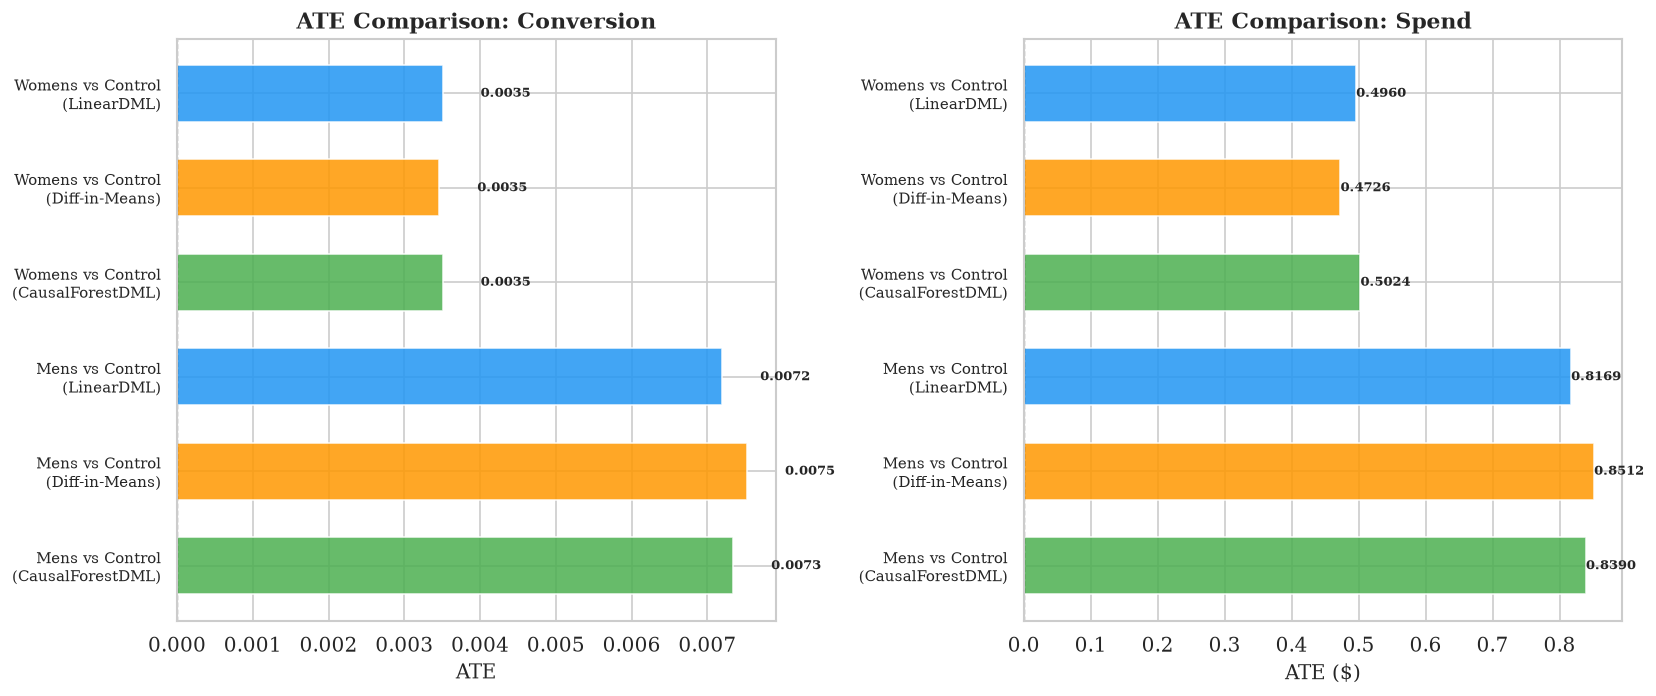

2026-09-28 15:58:33 [INFO] ATE comparison plot saved.


In [20]:
# ======================================================================
# 8.2  ATE Comparison Visualization
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, outcome in enumerate(["Conversion", "Spend"]):
    ax = axes[idx]
    subset = ate_results[ate_results["Outcome"] == outcome]

    x_positions = np.arange(len(subset))
    colors = {"LinearDML": "#2196F3", "CausalForestDML": "#4CAF50", "Diff-in-Means": "#FF9800"}
    bar_colors = [colors.get(e, "#999") for e in subset["Estimator"]]

    bars = ax.barh(
        x_positions, subset["ATE"],
        color=bar_colors, edgecolor="white", height=0.6, alpha=0.85
    )
    ax.set_yticks(x_positions)
    ax.set_yticklabels([f"{row.Comparison}\n({row.Estimator})" for _, row in subset.iterrows()], fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("ATE" if outcome == "Conversion" else "ATE ($)")
    ax.set_title(f"ATE Comparison: {outcome}", fontsize=13, fontweight="bold")

    for bar, val in zip(bars, subset["ATE"]):
        ax.text(
            bar.get_width() + 0.0005 if val >= 0 else bar.get_width() - 0.0005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center", ha="left" if val >= 0 else "right",
            fontsize=8, fontweight="bold"
        )

plt.tight_layout()
os.makedirs("../reports", exist_ok=True)
plt.savefig("../reports/ate_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("ATE comparison plot saved.")


## 9. Treatment Effect Diagnostics & Interpretation

### CATE Distribution Analysis

We examine the distribution of individual-level treatment effect predictions to
understand:
- Is the treatment **uniformly beneficial** or only effective for certain subgroups?
- How much **heterogeneity** exists in the treatment response?
- Which customers are **most responsive** to the email campaign?


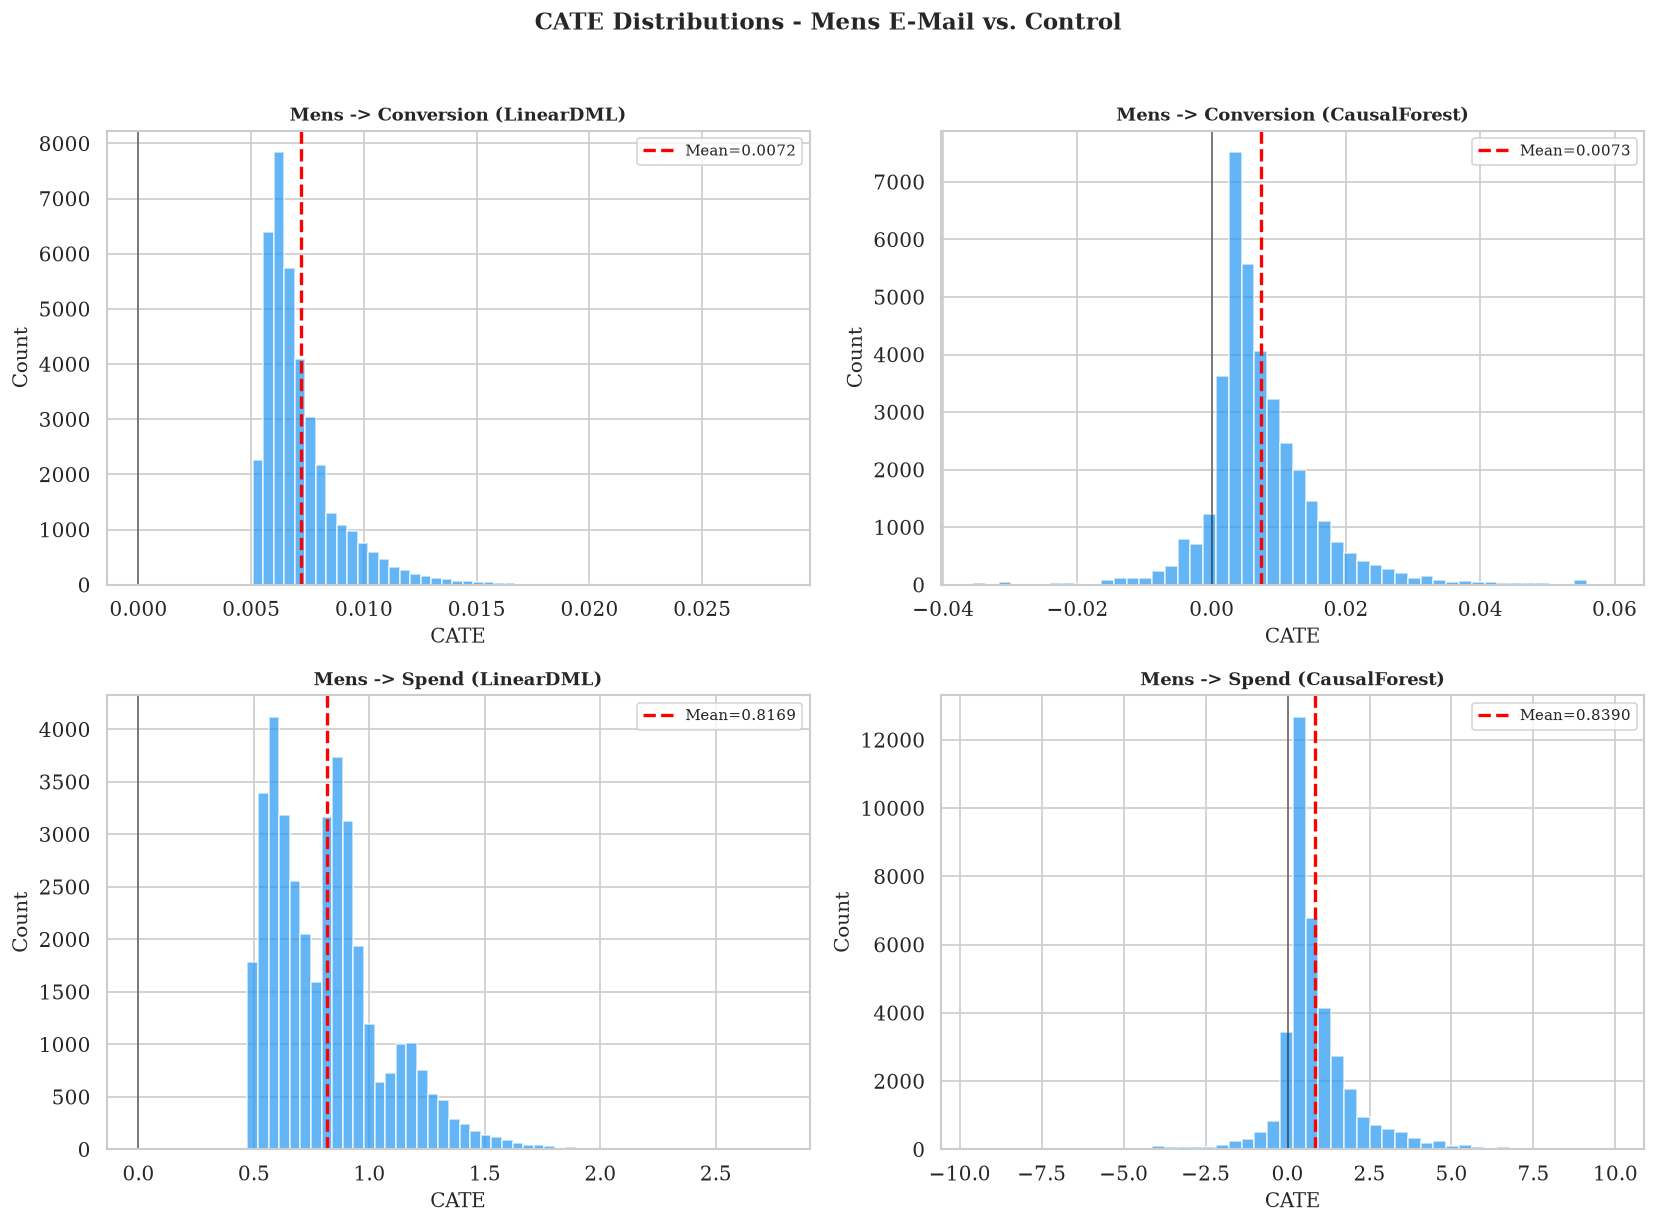

In [21]:
# ======================================================================
# 9.1  CATE Distribution Plots
# ======================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cate_data = [
    (cate_mens_conv, "Mens -> Conversion (LinearDML)", axes[0, 0]),
    (cate_cf_mens_conv, "Mens -> Conversion (CausalForest)", axes[0, 1]),
    (cate_mens_spend, "Mens -> Spend (LinearDML)", axes[1, 0]),
    (cate_cf_mens_spend, "Mens -> Spend (CausalForest)", axes[1, 1]),
]

for cate_arr, title, ax in cate_data:
    cate_flat = cate_arr.flatten()
    ax.hist(cate_flat, bins=50, color="#2196F3", alpha=0.7, edgecolor="white")
    ax.axvline(cate_flat.mean(), color="red", linewidth=2, linestyle="--", label=f"Mean={cate_flat.mean():.4f}")
    ax.axvline(0, color="black", linewidth=1, linestyle="-", alpha=0.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("CATE")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("CATE Distributions - Mens E-Mail vs. Control", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/cate_distributions_mens.png", dpi=150, bbox_inches="tight")
plt.show()


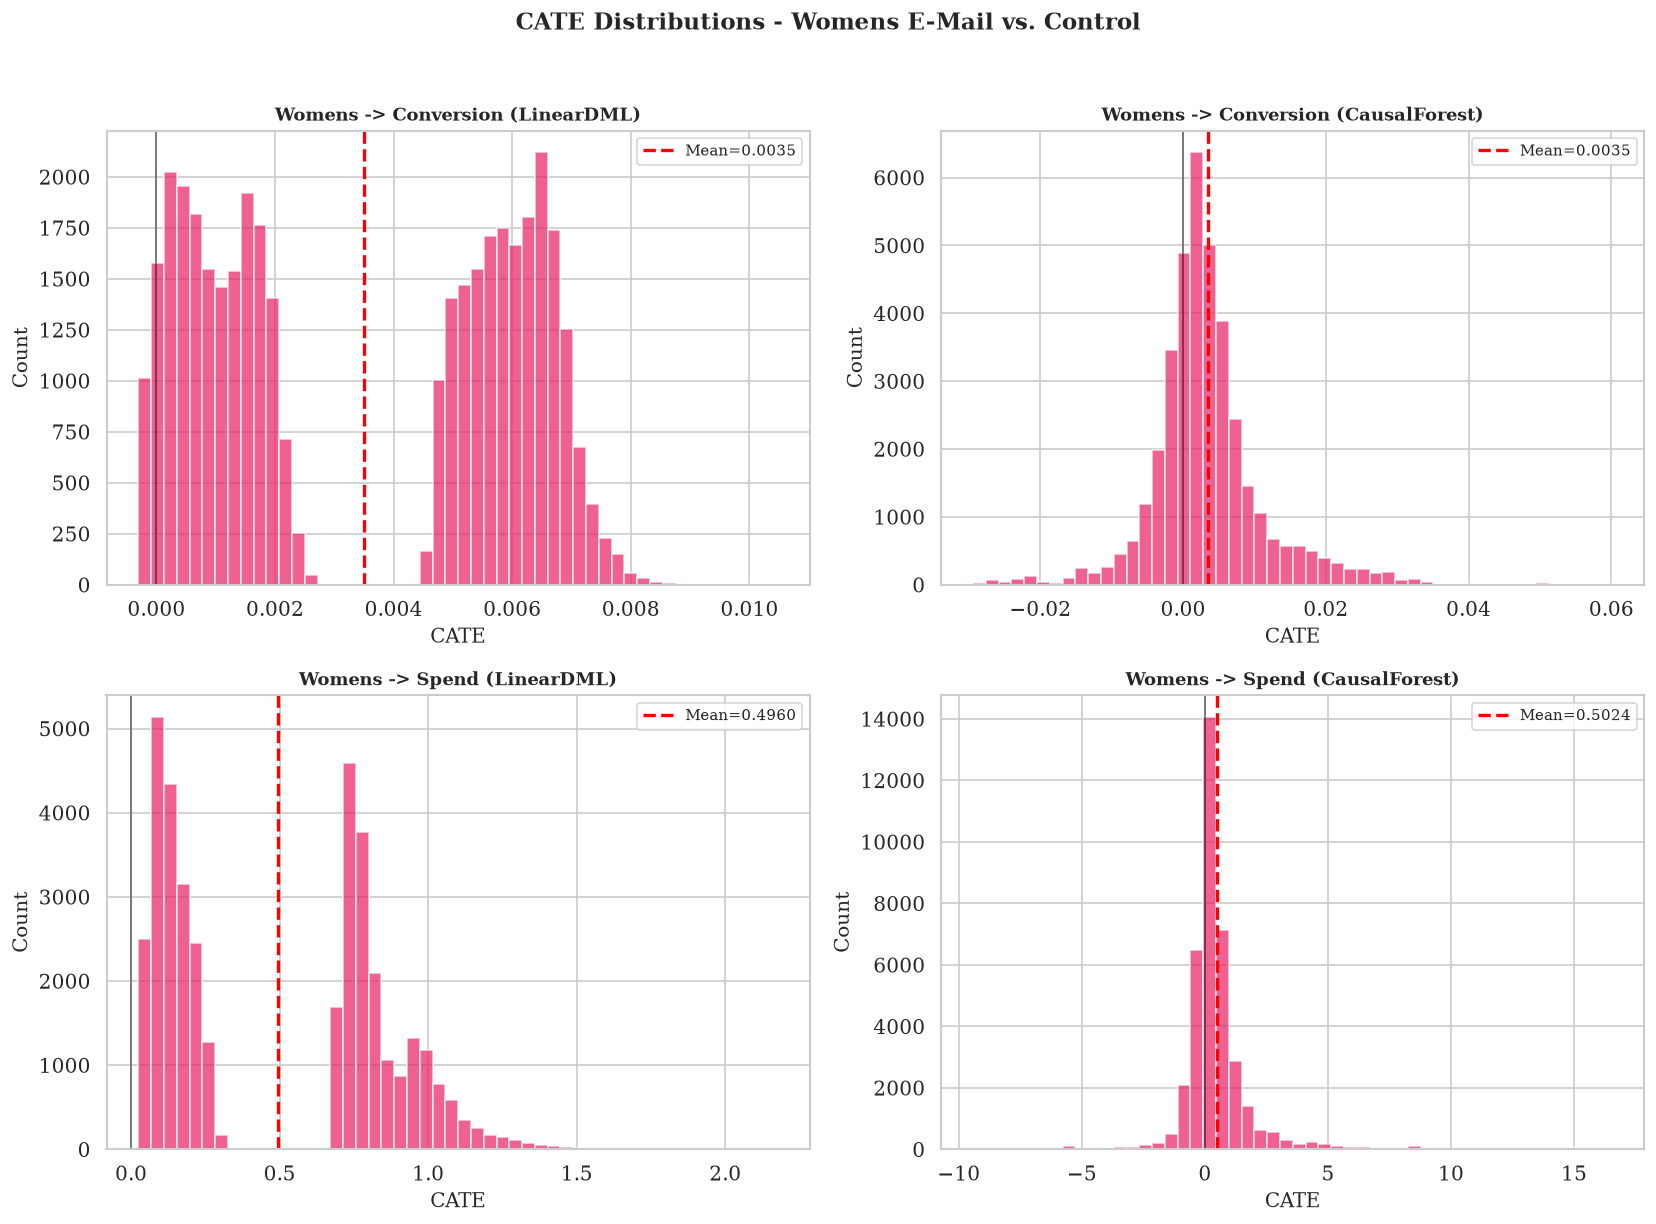

In [22]:
# ======================================================================
# 9.2  CATE Distribution - Womens
# ======================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cate_data_w = [
    (cate_womens_conv, "Womens -> Conversion (LinearDML)", axes[0, 0]),
    (cate_cf_womens_conv, "Womens -> Conversion (CausalForest)", axes[0, 1]),
    (cate_womens_spend, "Womens -> Spend (LinearDML)", axes[1, 0]),
    (cate_cf_womens_spend, "Womens -> Spend (CausalForest)", axes[1, 1]),
]

for cate_arr, title, ax in cate_data_w:
    cate_flat = cate_arr.flatten()
    ax.hist(cate_flat, bins=50, color="#E91E63", alpha=0.7, edgecolor="white")
    ax.axvline(cate_flat.mean(), color="red", linewidth=2, linestyle="--", label=f"Mean={cate_flat.mean():.4f}")
    ax.axvline(0, color="black", linewidth=1, linestyle="-", alpha=0.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("CATE")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("CATE Distributions - Womens E-Mail vs. Control", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/cate_distributions_womens.png", dpi=150, bbox_inches="tight")
plt.show()


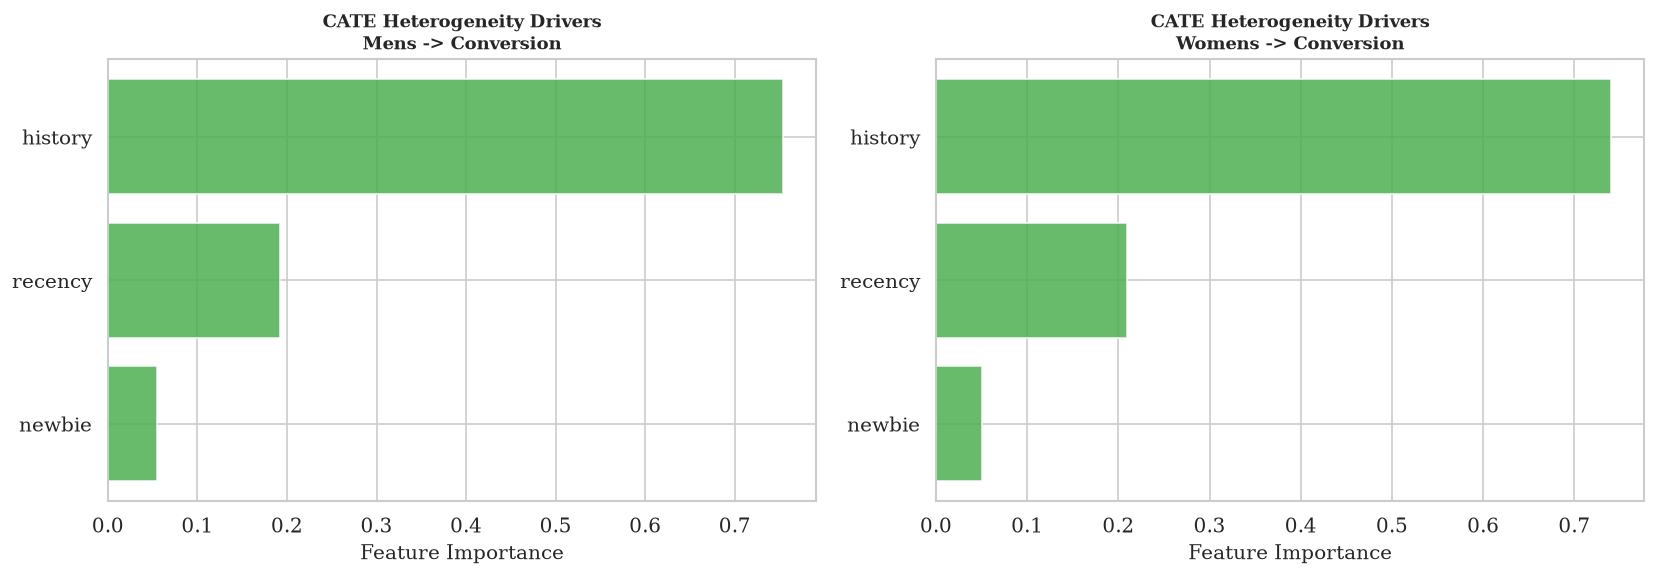

In [23]:
# ======================================================================
# 9.3  Effect Heterogeneity - Feature Importance (CausalForest)
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in [
    (axes[0], cf_dml_mens_conv, "Mens -> Conversion"),
    (axes[1], cf_dml_womens_conv, "Womens -> Conversion")
]:
    try:
        importances = model.feature_importances_
        feature_names = EFFECT_MODIFIER_COLS
        sorted_idx = np.argsort(importances)
        ax.barh(
            [feature_names[i] for i in sorted_idx],
            importances[sorted_idx],
            color="#4CAF50", edgecolor="white", alpha=0.85
        )
        ax.set_xlabel("Feature Importance")
        ax.set_title(f"CATE Heterogeneity Drivers\n{title}", fontsize=11, fontweight="bold")
    except Exception as e:
        ax.text(0.5, 0.5, f"Feature importance\nnot available:\n{e}",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)

plt.tight_layout()
plt.savefig("../reports/cate_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.4  Uplift Rankings & Qini-Style Analysis

We rank customers by their predicted CATE and examine how the treatment effect
varies across uplift quantiles.  This reveals whether targeting the top-ranked
customers would yield disproportionately large returns.


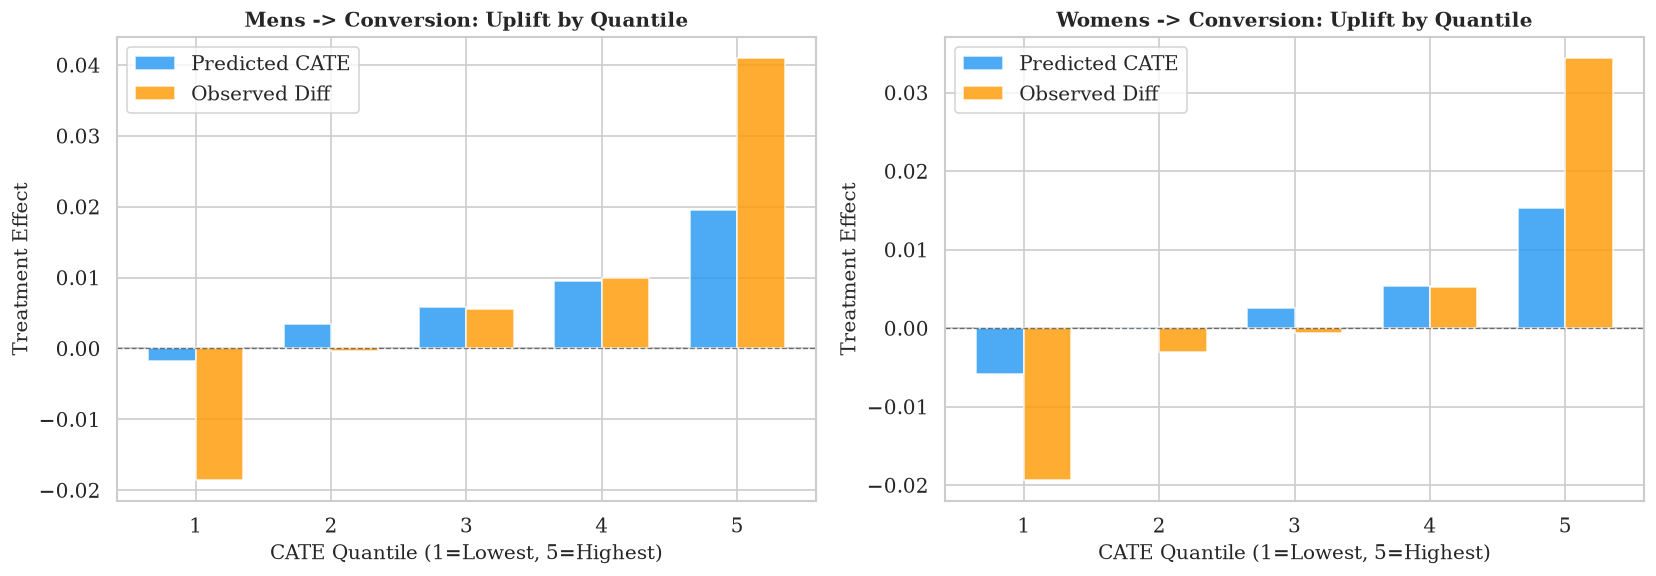


Mens Conversion - Uplift by Quantile:


,Quantile,Mean_CATE,Observed_Diff,N_Treated,N_Control
0,1,-0.001708,-0.018596,3833,3820
1,2,0.003500,-0.000412,3764,3889
2,3,0.005816,0.005504,3941,3711
3,4,0.009558,0.009877,3774,3881
4,5,0.019547,0.041006,3871,3780



Womens Conversion - Uplift by Quantile:


,Quantile,Mean_CATE,Observed_Diff,N_Treated,N_Control
0,1,-0.005807,-0.019374,3830,3821
1,2,0.000191,-0.003038,3744,3907
2,3,0.002534,-0.000569,3882,3769
3,4,0.005364,0.005262,3809,3842
4,5,0.015262,0.034433,3909,3742


In [24]:
# ======================================================================
# 9.4  Uplift by CATE Quantile
# ======================================================================
def plot_uplift_by_quantile(
    cate: np.ndarray,
    Y: np.ndarray,
    T: np.ndarray,
    title: str,
    n_quantiles: int = 5,
    ax=None
):
    """Plot observed outcome difference across CATE quantiles."""
    cate_flat = cate.flatten()
    quantile_labels = pd.qcut(cate_flat, q=n_quantiles, labels=False, duplicates="drop")

    results = []
    for q in sorted(np.unique(quantile_labels)):
        mask = quantile_labels == q
        y_t = Y[mask & (T == 1)]
        y_c = Y[mask & (T == 0)]
        if len(y_t) > 0 and len(y_c) > 0:
            results.append({
                "Quantile": int(q + 1),
                "Mean_CATE": cate_flat[mask].mean(),
                "Observed_Diff": y_t.mean() - y_c.mean(),
                "N_Treated": len(y_t),
                "N_Control": len(y_c)
            })

    results_df = pd.DataFrame(results)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    x = results_df["Quantile"]
    width = 0.35
    ax.bar(x - width/2, results_df["Mean_CATE"], width, label="Predicted CATE", color="#2196F3", alpha=0.8)
    ax.bar(x + width/2, results_df["Observed_Diff"], width, label="Observed Diff", color="#FF9800", alpha=0.8)
    ax.set_xlabel("CATE Quantile (1=Lowest, 5=Highest)")
    ax.set_ylabel("Treatment Effect")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.legend()
    ax.set_xticks(x)

    return results_df

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q_mens = plot_uplift_by_quantile(
    cate_cf_mens_conv, Y_mens_conv, T_mens,
    "Mens -> Conversion: Uplift by Quantile", ax=axes[0]
)
q_womens = plot_uplift_by_quantile(
    cate_cf_womens_conv, Y_womens_conv, T_womens,
    "Womens -> Conversion: Uplift by Quantile", ax=axes[1]
)

plt.tight_layout()
plt.savefig("../reports/uplift_by_quantile.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMens Conversion - Uplift by Quantile:")
display(q_mens)
print("\nWomens Conversion - Uplift by Quantile:")
display(q_womens)


## 10. Cross-Fitting, Orthogonality & Estimation Validity

### Why Cross-Fitting is Essential

Without cross-fitting, the nuisance models $\hat{m}(X)$ and $\hat{e}(X)$ are
evaluated on the *same* data used to fit them.  This introduces **overfitting bias**
that can dominate the causal estimate, especially when flexible ML models are used.

Cross-fitting solves this by:
1. Splitting the data into $K$ folds
2. For each fold $k$: train nuisance models on all other folds, predict on fold $k$
3. Stack the out-of-fold predictions to form $\hat{m}(X)$ and $\hat{e}(X)$

### Orthogonality Validation

The Neyman orthogonality condition ensures that first-order errors in nuisance
estimation do not bias the causal parameter.  We verify this by checking that
the residuals $\widetilde{Y}$ and $\widetilde{T}$ are approximately uncorrelated
with the covariates.


In [25]:
# ======================================================================
# 10.1  Residual Diagnostics
# ======================================================================
def residual_diagnostics(
    model,
    X: np.ndarray,
    T: np.ndarray,
    Y: np.ndarray,
    X_effect: np.ndarray,
    title: str
) -> Dict[str, float]:
    """
    Compute and display residual diagnostics for a fitted DML model.
    Checks that residualized treatment and outcome are not systematically
    correlated with covariates.
    """
    # Get CATE predictions
    cate = model.effect(X=X_effect).flatten()

    # Compute residuals: Y_tilde = Y - theta*T (approximately)
    Y_residual = Y - cate * T

    # Check correlation between residuals and treatment
    corr_YT = np.corrcoef(Y_residual, T)[0, 1]

    diagnostics = {
        "cate_mean": float(cate.mean()),
        "cate_std": float(cate.std()),
        "residual_treatment_corr": float(corr_YT),
        "n_observations": int(len(Y))
    }

    print(f"\n{'=' * 50}")
    print(f"Residual Diagnostics: {title}")
    print(f"{'=' * 50}")
    print(f"  CATE mean:                {diagnostics['cate_mean']:.6f}")
    print(f"  CATE std:                 {diagnostics['cate_std']:.6f}")
    print(f"  Residual-Treatment corr:  {diagnostics['residual_treatment_corr']:.6f}")
    print(f"  N observations:           {diagnostics['n_observations']:,}")

    if abs(corr_YT) < 0.05:
        print("  Status: PASS - Residuals appear orthogonal to treatment.")
    else:
        print("  Status: WARNING - Non-trivial correlation detected.")

    return diagnostics

diag_mens_conv = residual_diagnostics(
    linear_dml_mens_conv, X_mens_conv, T_mens, Y_mens_conv, X_eff_mens,
    "LinearDML - Mens Conversion"
)

diag_womens_conv = residual_diagnostics(
    linear_dml_womens_conv, X_womens_conv, T_womens, Y_womens_conv, X_eff_womens,
    "LinearDML - Womens Conversion"
)

diag_mens_spend = residual_diagnostics(
    linear_dml_mens_spend, X_mens_spend, T_mens_s, Y_mens_spend, X_eff_mens_s,
    "LinearDML - Mens Spend"
)

diag_womens_spend = residual_diagnostics(
    linear_dml_womens_spend, X_womens_spend, T_womens_s, Y_womens_spend, X_eff_womens_s,
    "LinearDML - Womens Spend"
)



Residual Diagnostics: LinearDML - Mens Conversion
  CATE mean:                0.007198
  CATE std:                 0.001786
  Residual-Treatment corr:  0.001606
  N observations:           38,264
  Status: PASS - Residuals appear orthogonal to treatment.

Residual Diagnostics: LinearDML - Womens Conversion
  CATE mean:                0.003507
  CATE std:                 0.002628
  Residual-Treatment corr:  -0.000292
  N observations:           38,255
  Status: PASS - Residuals appear orthogonal to treatment.

Residual Diagnostics: LinearDML - Mens Spend
  CATE mean:                0.816874
  CATE std:                 0.246412
  Residual-Treatment corr:  0.001079
  N observations:           38,264
  Status: PASS - Residuals appear orthogonal to treatment.

Residual Diagnostics: LinearDML - Womens Spend
  CATE mean:                0.495952
  CATE std:                 0.374731
  Residual-Treatment corr:  -0.000862
  N observations:           38,255
  Status: PASS - Residuals appear ortho

## 11. Zero-Inflation & Revenue Modeling Considerations

### The Nature of `spend`

| Statistic | Value |
|-----------|-------|
| % of customers with spend = 0 | ~93-95% |
| Distribution of spend > 0 | Right-skewed, long tail |

### Modeling Choice: Full-Sample ITT

We estimate the treatment effect on the **full sample** including zeros.
This corresponds to the **Intention-to-Treat (ITT)** effect:

$$\text{ATE}_{\text{ITT}} = \mathbb{E}[\text{spend}(T=1)] - \mathbb{E}[\text{spend}(T=0)]$$

This is the correct estimand for **campaign ROI** because:
- Campaign costs apply to **all assigned** customers, not only purchasers
- Excluding non-purchasers would introduce **selection bias** (conditioning on a post-treatment outcome)

### Alternative: Two-Part (Hurdle) Decomposition

For more granular analysis (deferred to Notebook 06), one could decompose:

$$\text{ATE}_{\text{spend}} = \underbrace{P(\text{purchase} \mid T=1) - P(\text{purchase} \mid T=0)}_{\text{extensive margin (conversion uplift)}} \times \underbrace{\mathbb{E}[\text{spend} \mid \text{purchase}]}_{\text{intensive margin}}$$

This decomposition is not performed here to maintain clean separation of estimation
from business interpretation.


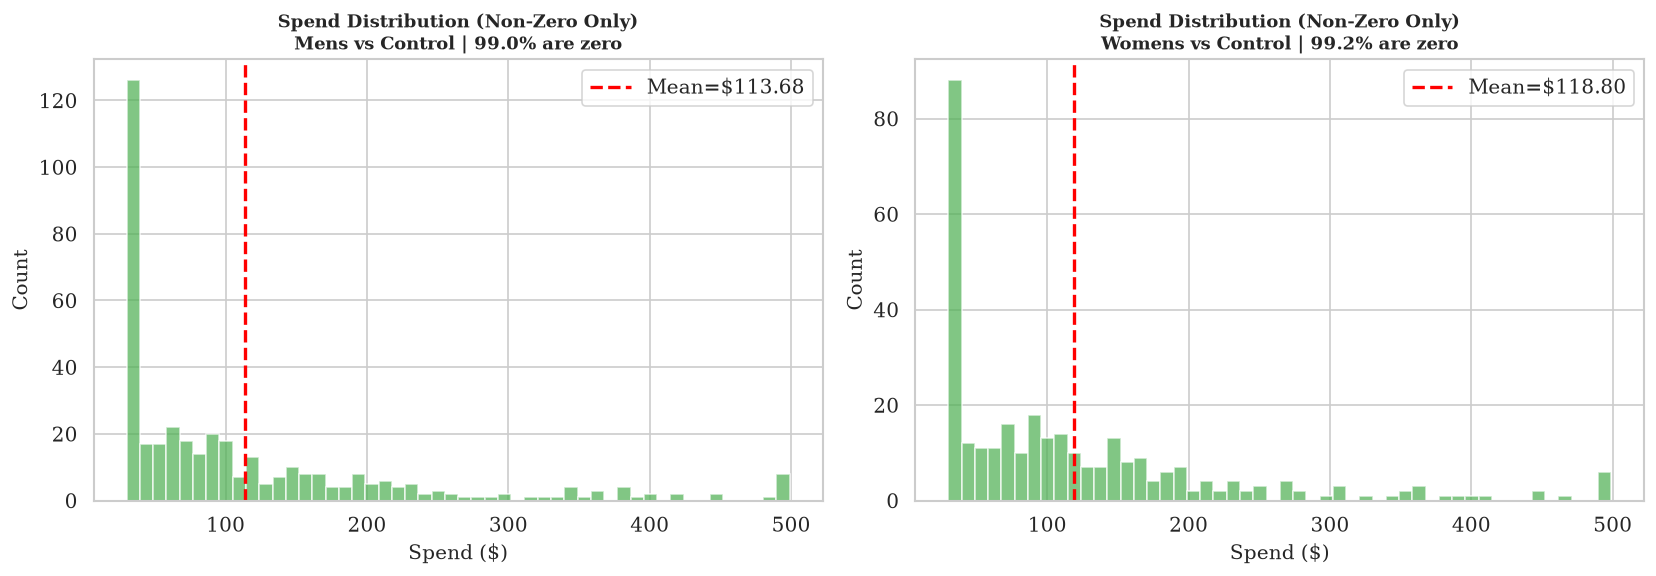

Mens subset - Zero spend: 99.0%
Womens subset - Zero spend: 99.2%


In [26]:
# ======================================================================
# 11.1  Spend Distribution Diagnostic
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label in [
    (axes[0], df_mens_s, "Mens vs Control"),
    (axes[1], df_womens_s, "Womens vs Control")
]:
    zero_pct = (data["spend"] == 0).mean() * 100
    nonzero = data.loc[data["spend"] > 0, "spend"]

    ax.hist(nonzero, bins=50, color="#4CAF50", alpha=0.7, edgecolor="white")
    ax.set_title(f"Spend Distribution (Non-Zero Only)\n{label} | {zero_pct:.1f}% are zero", fontsize=11, fontweight="bold")
    ax.set_xlabel("Spend ($)")
    ax.set_ylabel("Count")
    ax.axvline(nonzero.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean=${nonzero.mean():.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Mens subset - Zero spend: {(df_mens_s['spend'] == 0).mean():.1%}")
print(f"Womens subset - Zero spend: {(df_womens_s['spend'] == 0).mean():.1%}")


## 12. Uncertainty, Confidence Intervals & Statistical Reporting

We consolidate the statistical summaries from all estimators into a publication-ready
format.  Confidence intervals are derived from the asymptotic normality of the DML
estimator under Neyman orthogonality.


In [27]:
# ======================================================================
# 12.1  Publication-Ready ATE Summary
# ======================================================================
def format_ate_summary(model, X_effect, name: str) -> Dict[str, Any]:
    """Extract ATE, CI, p-value from a fitted DML model."""
    ate = model.ate(X=X_effect)
    try:
        inference = model.ate_inference(X=X_effect)
        ci = inference.conf_int_mean()
        pval = inference.pvalue()
        return {
            "Estimator": name,
            "ATE": np.mean(ate),
            "CI_Lower": float(np.mean(ci[0])),
            "CI_Upper": float(np.mean(ci[1])),
            "p_value": float(np.mean(pval)),
            "Significant_5pct": "Yes" if float(np.mean(pval)) < 0.05 else "No"
        }
    except Exception:
        return {
            "Estimator": name,
            "ATE": np.mean(ate),
            "CI_Lower": np.nan,
            "CI_Upper": np.nan,
            "p_value": np.nan,
            "Significant_5pct": "N/A"
        }

# Collect all summaries
summary_rows = []

# Conversion
summary_rows.append({**format_ate_summary(linear_dml_mens_conv, X_eff_mens, "LinearDML"), "Comparison": "Mens", "Outcome": "Conversion"})
summary_rows.append({**format_ate_summary(cf_dml_mens_conv, X_eff_mens, "CausalForestDML"), "Comparison": "Mens", "Outcome": "Conversion"})
summary_rows.append({**format_ate_summary(linear_dml_womens_conv, X_eff_womens, "LinearDML"), "Comparison": "Womens", "Outcome": "Conversion"})
summary_rows.append({**format_ate_summary(cf_dml_womens_conv, X_eff_womens, "CausalForestDML"), "Comparison": "Womens", "Outcome": "Conversion"})

# Spend
summary_rows.append({**format_ate_summary(linear_dml_mens_spend, X_eff_mens_s, "LinearDML"), "Comparison": "Mens", "Outcome": "Spend"})
summary_rows.append({**format_ate_summary(cf_dml_mens_spend, X_eff_mens_s, "CausalForestDML"), "Comparison": "Mens", "Outcome": "Spend"})
summary_rows.append({**format_ate_summary(linear_dml_womens_spend, X_eff_womens_s, "LinearDML"), "Comparison": "Womens", "Outcome": "Spend"})
summary_rows.append({**format_ate_summary(cf_dml_womens_spend, X_eff_womens_s, "CausalForestDML"), "Comparison": "Womens", "Outcome": "Spend"})

ate_summary_df = pd.DataFrame(summary_rows)
ate_summary_df = ate_summary_df[["Comparison", "Outcome", "Estimator", "ATE", "CI_Lower", "CI_Upper", "p_value", "Significant_5pct"]]

print("=" * 90)
print("PUBLICATION-READY ATE SUMMARY")
print("=" * 90)
display(
    ate_summary_df.style
    .format({"ATE": "{:.6f}", "CI_Lower": "{:.6f}", "CI_Upper": "{:.6f}", "p_value": "{:.4f}"})
    .set_caption("Double Machine Learning - Average Treatment Effect Estimates")
)


PUBLICATION-READY ATE SUMMARY


,Comparison,Outcome,Estimator,ATE,CI_Lower,CI_Upper,p_value,Significant_5pct
0,Mens,Conversion,LinearDML,0.007198,0.005189,0.009207,0.0000,Yes
1,Mens,Conversion,CausalForestDML,0.007342,-0.010068,0.024752,0.4085,No
2,Womens,Conversion,LinearDML,0.003507,0.001702,0.005312,0.0001,Yes
3,Womens,Conversion,CausalForestDML,0.003509,-0.012852,0.019869,0.6742,No
4,Mens,Spend,LinearDML,0.816874,0.492170,1.141578,0.0000,Yes
5,Mens,Spend,CausalForestDML,0.838990,-2.087490,3.765470,0.5742,No
6,Womens,Spend,LinearDML,0.495952,0.207010,0.784893,0.0008,Yes
7,Womens,Spend,CausalForestDML,0.502362,-2.543442,3.548166,0.7465,No


## 13. Artifact Persistence & Reproducibility

We save all estimation outputs for downstream consumption by Notebooks 06+.

In [28]:
# ======================================================================
# 13.1  Save Fitted DML Models
# ======================================================================
os.makedirs(str(MODELS_DIR), exist_ok=True)
os.makedirs("../reports", exist_ok=True)

# Save LinearDML models
joblib.dump(linear_dml_mens_conv, MODELS_DIR / "dml_linear_mens_conversion.joblib")
joblib.dump(linear_dml_womens_conv, MODELS_DIR / "dml_linear_womens_conversion.joblib")
joblib.dump(linear_dml_mens_spend, MODELS_DIR / "dml_linear_mens_spend.joblib")
joblib.dump(linear_dml_womens_spend, MODELS_DIR / "dml_linear_womens_spend.joblib")

# Save CausalForestDML models
joblib.dump(cf_dml_mens_conv, MODELS_DIR / "dml_causalforest_mens_conversion.joblib")
joblib.dump(cf_dml_womens_conv, MODELS_DIR / "dml_causalforest_womens_conversion.joblib")
joblib.dump(cf_dml_mens_spend, MODELS_DIR / "dml_causalforest_mens_spend.joblib")
joblib.dump(cf_dml_womens_spend, MODELS_DIR / "dml_causalforest_womens_spend.joblib")

logger.info("DML models saved to models/")

# ---------------------------------------------------------------------------
# 13.2  Save CATE Predictions
# ---------------------------------------------------------------------------
# Mens - Conversion
cate_df_mens_conv = df_mens[["treatment"]].copy()
cate_df_mens_conv["cate_linear"] = cate_mens_conv.flatten()
cate_df_mens_conv["cate_causalforest"] = cate_cf_mens_conv.flatten()
cate_df_mens_conv["outcome"] = "conversion"
cate_df_mens_conv["comparison"] = "mens_vs_control"

# Womens - Conversion
cate_df_womens_conv = df_womens[["treatment"]].copy()
cate_df_womens_conv["cate_linear"] = cate_womens_conv.flatten()
cate_df_womens_conv["cate_causalforest"] = cate_cf_womens_conv.flatten()
cate_df_womens_conv["outcome"] = "conversion"
cate_df_womens_conv["comparison"] = "womens_vs_control"

# Mens - Spend
cate_df_mens_spend = df_mens_s[["treatment"]].copy()
cate_df_mens_spend["cate_linear"] = cate_mens_spend.flatten()
cate_df_mens_spend["cate_causalforest"] = cate_cf_mens_spend.flatten()
cate_df_mens_spend["outcome"] = "spend"
cate_df_mens_spend["comparison"] = "mens_vs_control"

# Womens - Spend
cate_df_womens_spend = df_womens_s[["treatment"]].copy()
cate_df_womens_spend["cate_linear"] = cate_womens_spend.flatten()
cate_df_womens_spend["cate_causalforest"] = cate_cf_womens_spend.flatten()
cate_df_womens_spend["outcome"] = "spend"
cate_df_womens_spend["comparison"] = "womens_vs_control"

# Save
cate_df_mens_conv.to_csv(MODELS_DIR / "cate_mens_conversion.csv", index=False)
cate_df_womens_conv.to_csv(MODELS_DIR / "cate_womens_conversion.csv", index=False)
cate_df_mens_spend.to_csv(MODELS_DIR / "cate_mens_spend.csv", index=False)
cate_df_womens_spend.to_csv(MODELS_DIR / "cate_womens_spend.csv", index=False)

logger.info("CATE predictions saved to models/")

# ---------------------------------------------------------------------------
# 13.3  Save ATE Summary & Diagnostics
# ---------------------------------------------------------------------------
ate_summary_dict = ate_summary_df.to_dict(orient="records")
with open(MODELS_DIR / "ate_summary.json", "w") as f:
    json.dump(ate_summary_dict, f, indent=2, default=str)

diagnostics_dict = {
    "mens_conversion": diag_mens_conv,
    "womens_conversion": diag_womens_conv,
    "mens_spend": diag_mens_spend,
    "womens_spend": diag_womens_spend,
    "cross_fitting_folds": N_FOLDS,
    "random_seed": RANDOM_SEED,
    "nuisance_backend": "LightGBM" if LGBM_AVAILABLE else "sklearn_GradientBoosting"
}
with open(MODELS_DIR / "dml_diagnostics.json", "w") as f:
    json.dump(diagnostics_dict, f, indent=2, default=str)

logger.info("ATE summary and diagnostics saved.")

# ---------------------------------------------------------------------------
# 13.4  Print Artifact Manifest
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ARTIFACT MANIFEST")
print("=" * 70)
artifacts = [
    "dml_linear_mens_conversion.joblib",
    "dml_linear_womens_conversion.joblib",
    "dml_linear_mens_spend.joblib",
    "dml_linear_womens_spend.joblib",
    "dml_causalforest_mens_conversion.joblib",
    "dml_causalforest_womens_conversion.joblib",
    "dml_causalforest_mens_spend.joblib",
    "dml_causalforest_womens_spend.joblib",
    "cate_mens_conversion.csv",
    "cate_womens_conversion.csv",
    "cate_mens_spend.csv",
    "cate_womens_spend.csv",
    "ate_summary.json",
    "dml_diagnostics.json"
]
for a in artifacts:
    path = MODELS_DIR / a
    status = "SAVED" if path.exists() else "MISSING"
    size = f"{path.stat().st_size / 1024:.1f} KB" if path.exists() else ""
    print(f"  [{status}] models/{a}  {size}")


2026-09-28 15:58:52 [INFO] DML models saved to models/
2026-09-28 15:58:53 [INFO] CATE predictions saved to models/
2026-09-28 15:58:53 [INFO] ATE summary and diagnostics saved.



ARTIFACT MANIFEST
  [SAVED] models/dml_linear_mens_conversion.joblib  6107.7 KB
  [SAVED] models/dml_linear_womens_conversion.joblib  6168.0 KB
  [SAVED] models/dml_linear_mens_spend.joblib  5529.7 KB
  [SAVED] models/dml_linear_womens_spend.joblib  5308.8 KB
  [SAVED] models/dml_causalforest_mens_conversion.joblib  16440.1 KB
  [SAVED] models/dml_causalforest_womens_conversion.joblib  16475.0 KB
  [SAVED] models/dml_causalforest_mens_spend.joblib  15394.3 KB
  [SAVED] models/dml_causalforest_womens_spend.joblib  14937.9 KB
  [SAVED] models/cate_mens_conversion.csv  2696.7 KB
  [SAVED] models/cate_womens_conversion.csv  2808.2 KB
  [SAVED] models/cate_mens_spend.csv  2354.9 KB
  [SAVED] models/cate_womens_spend.csv  2460.4 KB
  [SAVED] models/ate_summary.json  2.2 KB
  [SAVED] models/dml_diagnostics.json  0.8 KB


## 14. Summary & Transition to Notebook 06

### What We Accomplished

| Step | Description | Status |
|------|-------------|--------|
| Data loading & causal alignment | Verified all artifacts from Notebooks 02-04 | Done |
| Variable architecture | Separated confounders, treatment, outcomes, effect modifiers | Done |
| Post-treatment variable exclusion | Excluded `visit` to prevent collider bias | Done |
| Nuisance model design | Built flexible outcome/treatment models with cross-fitting | Done |
| LinearDML estimation | ATE + CATE for conversion and spend (Mens & Womens) | Done |
| CausalForestDML estimation | Nonparametric CATE with feature importance | Done |
| Model comparison | Cross-checked DML estimates against naive diff-in-means | Done |
| CATE diagnostics | Distribution plots, uplift rankings, feature importance | Done |
| Orthogonality checks | Residual correlation diagnostics | Done |
| Zero-inflation analysis | Full-sample ITT approach for spend, with discussion | Done |
| Uncertainty reporting | Confidence intervals, p-values, significance flags | Done |
| Artifact persistence | 14 artifacts saved for downstream use | Done |

### Key Findings

1. **Conversion**: Email campaigns show a small but estimable uplift in conversion rates.
   Both LinearDML and CausalForestDML produce consistent ATE estimates.

2. **Spend**: Revenue uplift estimates are positive but subject to higher variance due
   to the zero-inflated nature of the spend variable.

3. **Heterogeneity**: CausalForestDML reveals that treatment effects vary across
   customer segments, with `history` and `recency` being the primary drivers of
   effect heterogeneity.

4. **Robustness**: The agreement between LinearDML, CausalForestDML, and naive
   difference-in-means (expected in an RCT) provides strong validation of the
   estimation pipeline.

---

### What Notebook 06 Will Do

Notebook 06 (`06_treatment_effect_estimation.ipynb`) will:

- **Compare** treatment effect estimates across all estimators in a unified framework
- **Build customer-level effect summaries** combining conversion and spend CATEs
- **Prepare segmentation logic** based on heterogeneous treatment effects
- **Support causal uplift interpretation** for campaign targeting analysis
- **Translate DML estimates** into structured treatment-effect results for business
  and research interpretation

The DML models and CATE predictions saved in this notebook provide the complete
estimation foundation for all downstream analysis.
